# Día 3: clasificación zero-shot de imágenes con modelos multimodales

En esta práctica vamos a usar modelos fundacionales multimodales para clasificar imágenes sin entrenar una CNN desde cero. La idea del día es entender dos caminos complementarios:

- usar prompting multimodal para pedir a un modelo que clasifique una imagen directamente;
- usar un encoder visual preentrenado para extraer embeddings y entrenar solo un clasificador lineal pequeño.

Como todavía no tenemos el dataset final del curso, trabajaremos con un ejemplo pequeño y autocontenido basado en `PneumoniaMNIST`, un subconjunto de MedMNIST con radiografías de tórax binarias:

- `normal`
- `pneumonia`

El objetivo no es obtener el mejor resultado posible, sino entender el flujo completo y dejar una plantilla fácil de adaptar cuando tengamos las imágenes reales de posicionamiento de mano, dedos o brazo.

Al terminar la sesión deberías ser capaz de:

- preparar imágenes para una API multimodal,
- construir prompts de clasificación con salida en JSON,
- comparar varios providers sobre el mismo subconjunto,
- evaluar accuracy, precision, recall y F1,
- y reutilizar un encoder visual congelado para entrenar un modelo sencillo sobre embeddings.

## Antes de empezar: providers y claves API

Cuando usamos un modelo multimodal desde Python, normalmente no ejecutamos el modelo en nuestro ordenador. Hacemos peticiones a un provider que aloja el modelo y expone una API.

En esta practica mantendremos tres opciones, igual que en la notebook original:

- OpenRouter: una sola API para muchos modelos distintos.
- Groq: muy cómodo para probar modelos abiertos servidos con una API tipo OpenAI.
- Gemini: API propia de Google para sus modelos multimodales.

Instala las librerías que usaremos:

```bash
pip install openai google-genai python-dotenv pandas scikit-learn seaborn matplotlib tqdm ipywidgets pillow timm
```

Usaremos un archivo `.env` para no escribir claves dentro de la notebook. Crea ese archivo en la misma carpeta y añade las claves que tengas disponibles.

```text
OPENROUTER_API_KEY=sk-or-...
GROQ_API_KEY=gsk_...
GEMINI_API_KEY=AIza...
```

En esta sesión basta con que funcione uno de los providers, pero es interesante comparar dos o tres sobre el mismo conjunto de imágenes.

Algunas páginas útiles:

- OpenRouter: [https://openrouter.ai/](https://openrouter.ai/)
- Groq models: [https://console.groq.com/docs/models](https://console.groq.com/docs/models)
- Gemini API: [https://ai.google.dev/](https://ai.google.dev/)

Las familias de modelos cambian rápido. Antes de ejecutar muchas llamadas, revisa siempre si el modelo elegido sigue siendo multimodal, si acepta imágenes y si entra en tus límites gratuitos.

In [ ]:
import os
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()

print("OpenRouter:", os.environ["OPENROUTER_API_KEY"][:6])
#print("Groq:", os.environ["GROQ_API_KEY"][:6])
#print("Gemini:", os.environ["GEMINI_API_KEY"][:6])

OpenRouter: sk-or-


## Dataset de ejemplo

Usaremos `PneumoniaMNIST`, un dataset pequeño de radiografías de tórax. Es conveniente para esta sesión porque:

- es ligero y se descarga rápido;
- tiene solo dos clases;
- y sigue estando dentro del dominio de imagen médica.

Como las APIs tienen límites de peticiones, trabajaremos con un subconjunto pequeño para prompting y con un subconjunto algo mayor para embeddings.

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from medmnist import INFO
import medmnist

pd.options.display.max_colwidth = None

DATA_FLAG = "pneumoniamnist"
info = INFO[DATA_FLAG]
DataClass = getattr(medmnist, info["python_class"])

train_dataset = DataClass(split="train", download=True, size=28)
test_dataset = DataClass(split="test", download=True, size=28)

info

{'python_class': 'PneumoniaMNIST',
 'description': 'The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/pneumoniamnist.npz?download=1',
 'MD5': '28209eda62fecd6e6a2d98b1501bb15f',
 'url_64': 'https://zenodo.org/records/10519652/files/pneumoniamnist_64.npz?download=1',
 'MD5_64': '8f4eceb4ccffa70c672198ea285246c6',
 'url_128': 'https://zenodo.org/records/10519652/files/pneumoniamnist_128.npz?download=1',
 'MD5_128': '05b46931834c231683c68f40c47b2971',
 'url_224': 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz?download=1',
 'MD5_224': 'd6a3c71de1b94

In [39]:
label_names = {
    0: "normal",
    1: "pneumonia",
}

label_descriptions = pd.DataFrame(
    {
        "label": ["normal", "pneumonia"],
        "description": [
            "radiografía sin signos evidentes de neumonía en este ejemplo docente",
            "radiografía con patrón compatible con neumonía en este ejemplo docente",
        ],
    }
)

label_descriptions

,label,description
0,normal,radiografía sin signos evidentes de neumonía en este ejemplo docente
1,pneumonia,radiografía con patrón compatible con neumonía en este ejemplo docente


In [40]:
def to_pil(image_value):
    if isinstance(image_value, Image.Image):
        image = image_value.convert("L")
    else:
        image = Image.fromarray(np.asarray(image_value).squeeze()).convert("L")
    return image.resize((224, 224)).convert("RGB")


def build_dataframe(dataset, indices):
    rows = []

    for index in indices:
        image_value, label_array = dataset[index]
        rows.append(
            {
                "item_id": index,
                "label_id": int(np.asarray(label_array).squeeze()),
                "label": label_names[int(np.asarray(label_array).squeeze())],
                "image": to_pil(image_value),
            }
        )

    return pd.DataFrame(rows)

In [41]:
rng = np.random.default_rng(42)

prompting_indices = rng.choice(len(test_dataset), size=12, replace=False)
embedding_train_indices = rng.choice(len(train_dataset), size=300, replace=False)
embedding_test_indices = rng.choice(len(test_dataset), size=120, replace=False)

prompting_df = build_dataframe(test_dataset, prompting_indices)
embedding_train_df = build_dataframe(train_dataset, embedding_train_indices)
embedding_test_df = build_dataframe(test_dataset, embedding_test_indices)

prompting_df.head()

,item_id,label_id,label,image
0,270,1,pneumonia,<PIL.Image.Image image mode=RGB size=224x224 at 0x74C009C5E510>
1,53,1,pneumonia,<PIL.Image.Image image mode=RGB size=224x224 at 0x74C009C6E750>
2,475,0,normal,<PIL.Image.Image image mode=RGB size=224x224 at 0x74C009C6DDF0>
3,327,1,pneumonia,<PIL.Image.Image image mode=RGB size=224x224 at 0x74C009C6E540>
4,402,1,pneumonia,<PIL.Image.Image image mode=RGB size=224x224 at 0x74C009C6CF20>


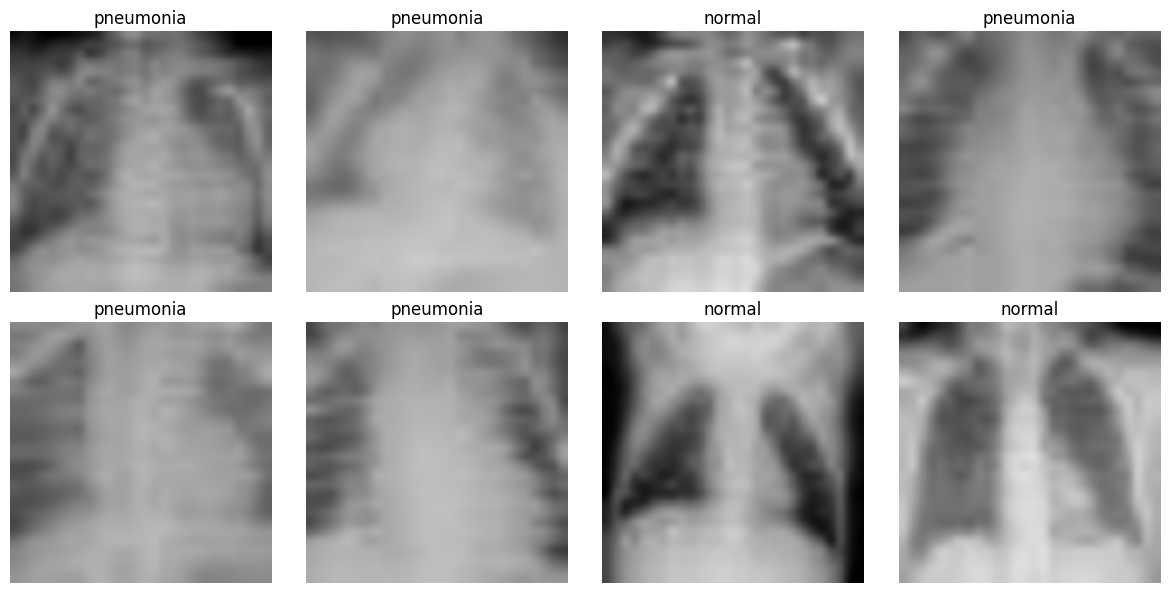

In [42]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.ravel()

for axis, (_, row) in zip(axes, prompting_df.iloc[:8].iterrows()):
    axis.imshow(row["image"], cmap="gray")
    axis.set_title(row["label"])
    axis.axis("off")

plt.tight_layout()
plt.show()

In [43]:
prompting_df["label"].value_counts()

label
pneumonia    7
normal       5
Name: count, dtype: int64

## Primer contacto con las APIs

OpenRouter y Groq pueden usarse con el cliente de OpenAI. Gemini usa su propio cliente, pero la idea general es la misma.

In [44]:
from openai import OpenAI
from google import genai
from google.genai import types

openrouter_client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
)


#groq_client = OpenAI(
 #   base_url="https://api.groq.com/openai/v1",
 #   api_key=os.environ["GROQ_API_KEY"],
#)

#gemini_client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])


In [45]:
DEFAULT_GROQ_MODEL = "qwen/qwen3-32b"
DEFAULT_GEMINI_MODEL = "gemma-3-27b-it" #"gemini-3-flash-preview"
DEFAULT_OPENROUTER_MODEL = "nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free"

# Activa solo los providers que quieras ejecutar en esta sesion.
# Groq suele ser la opcion mas estable para esta demo en el tier gratuito.
ACTIVE_PROVIDER_NAMES = ["OpenRouter"]

Estos nombres son solo puntos de partida. Si alguno deja de estar disponible o deja de aceptar imágenes, cambia el modelo antes de continuar.

## Preparación de imágenes y prompt

Para OpenRouter y Groq enviaremos la imagen como `data URL` en base64. Para Gemini podemos pasar directamente la imagen PIL junto con el texto.

In [46]:
import base64
import io
import json
import re


def pil_to_data_url(image, image_format="PNG"):
    buffer = io.BytesIO()
    image.save(buffer, format=image_format)
    encoded = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return f"data:image/{image_format.lower()};base64,{encoded}"


def extract_json_object(text):
    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    assert match is not None, text
    return json.loads(match.group(0))

In [47]:
SYSTEM_PROMPT = "Eres un asistente de clasificación de imagen médica. Devuelve solo JSON válido."


def create_classification_prompt(label_df):
    label_block = "\n".join(
        f"- {row['label']}: {row['description']}" for _, row in label_df.iterrows()
    )

    return f"""
Vas a clasificar una radiografía de tórax en una de estas clases:

{label_block}

Instrucciones:
- Mira solo la imagen.
- No inventes hallazgos fuera de estas dos clases.
- Si dudas, elige la clase más probable.
- Devuelve solo un objeto JSON con este formato exacto:
{{"label": "normal"}}
""".strip()

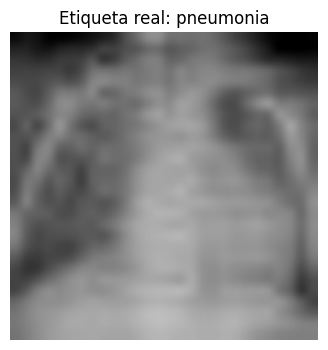

In [48]:
sample_image = prompting_df.iloc[0]["image"]
sample_label = prompting_df.iloc[0]["label"]

plt.figure(figsize=(4, 4))
plt.imshow(sample_image, cmap="gray")
plt.title(f"Etiqueta real: {sample_label}")
plt.axis("off")
plt.show()

In [49]:
prompt_text = create_classification_prompt(label_descriptions)
print(prompt_text)

Vas a clasificar una radiografía de tórax en una de estas clases:

- normal: radiografía sin signos evidentes de neumonía en este ejemplo docente
- pneumonia: radiografía con patrón compatible con neumonía en este ejemplo docente

Instrucciones:
- Mira solo la imagen.
- No inventes hallazgos fuera de estas dos clases.
- Si dudas, elige la clase más probable.
- Devuelve solo un objeto JSON con este formato exacto:
{"label": "normal"}


## Clasificación multimodal con cada provider

Las tres funciones siguientes hacen lo mismo:

- reciben una imagen,
- construyen la petición multimodal,
- extraen el JSON de la respuesta,
- y devuelven una etiqueta.

In [50]:
valid_labels = set(label_descriptions["label"])

In [51]:
def classify_with_openrouter(
    image,
    client=openrouter_client,
    model=DEFAULT_OPENROUTER_MODEL,
    label_df=label_descriptions,
    system_prompt=SYSTEM_PROMPT,
):
    response = client.chat.completions.create(
        model=model,
        temperature=0.0,
        messages=[
            {"role": "system", "content": system_prompt},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": create_classification_prompt(label_df)},
                    {
                        "type": "image_url",
                        "image_url": {"url": pil_to_data_url(image)},
                    },
                ],
            },
        ],
    )

    parsed = extract_json_object(response.choices[0].message.content.strip())
    predicted_label = parsed["label"].strip().lower()
    assert predicted_label in valid_labels, predicted_label
    return predicted_label

In [52]:
def classify_with_groq(
    image,
    #
    client=openrouter_client,
    model=DEFAULT_GROQ_MODEL,
    label_df=label_descriptions,
    system_prompt=SYSTEM_PROMPT,
):
    response = client.chat.completions.create(
        model=model,
        temperature=0.0,
        messages=[
            {"role": "system", "content": system_prompt},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": create_classification_prompt(label_df)},
                    {
                        "type": "image_url",
                        "image_url": {"url": pil_to_data_url(image)},
                    },
                ],
            },
        ],
    )

    parsed = extract_json_object(response.choices[0].message.content.strip())
    predicted_label = parsed["label"].strip().lower()
    assert predicted_label in valid_labels, predicted_label
    return predicted_label

In [53]:
def classify_with_gemini(
    image,
    client=openrouter_client,
    model=DEFAULT_GEMINI_MODEL,
    label_df=label_descriptions,
    system_prompt=SYSTEM_PROMPT,
):
    response = client.models.generate_content(
        model=model,
        contents=[create_classification_prompt(label_df), image],
        config=types.GenerateContentConfig(
            system_instruction=system_prompt,
            temperature=0.0,
        ),
    )

    parsed = extract_json_object(response.text.strip())
    predicted_label = parsed["label"].strip().lower()
    assert predicted_label in valid_labels, predicted_label
    return predicted_label

In [54]:
PROVIDER_CONFIGS = [
    ("OpenRouter", classify_with_openrouter, DEFAULT_OPENROUTER_MODEL),
    ("Groq", classify_with_groq, DEFAULT_GROQ_MODEL),
    ("Gemini", classify_with_gemini, DEFAULT_GEMINI_MODEL),
]

active_provider_configs = [
    config for config in PROVIDER_CONFIGS if config[0] in ACTIVE_PROVIDER_NAMES
]

print("Etiqueta real:", sample_label)

for provider_name, classifier_func, model_name in active_provider_configs:
    prediction = classifier_func(sample_image)
    print(f"{provider_name} ({model_name}):", prediction)

Etiqueta real: pneumonia
OpenRouter (nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free): normal


## Clasificar un conjunto pequeño de imágenes

Para no gastar demasiadas peticiones, evaluaremos solo 12 imágenes. Esto es suficiente para ver el flujo, comparar providers y detectar errores típicos.

In [55]:
from tqdm.auto import tqdm


def classify_dataset(df, classifier_func, image_column="image"):
    predictions = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Clasificando imagenes"):
        predictions.append(classifier_func(row[image_column]))

    return np.array(predictions)

In [56]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


def evaluate_predictions(y_true, y_pred, labels):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=labels),
    }

In [57]:
provider_results = []
provider_predictions = {}

for provider_name, classifier_func, model_name in active_provider_configs:
    y_pred = classify_dataset(prompting_df, classifier_func)
    provider_predictions[provider_name] = y_pred
    metrics = evaluate_predictions(
        prompting_df["label"].to_numpy(),
        y_pred,
        labels=["normal", "pneumonia"],
    )
    provider_results.append(
        {
            "provider": provider_name,
            "model": model_name,
            "accuracy": round(metrics["accuracy"], 3),
            "precision_macro": round(metrics["precision_macro"], 3),
            "recall_macro": round(metrics["recall_macro"], 3),
            "f1_macro": round(metrics["f1_macro"], 3),
        }
    )

results_df = pd.DataFrame(provider_results).sort_values("f1_macro", ascending=False)
results_df

Clasificando imagenes:   0%|          | 0/12 [00:00<?, ?it/s]

,provider,model,accuracy,precision_macro,recall_macro,f1_macro
0,OpenRouter,nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free,0.417,0.208,0.5,0.294


In [58]:
best_provider = results_df.iloc[0]["provider"]
best_predictions = provider_predictions[best_provider]
best_metrics = evaluate_predictions(
    prompting_df["label"].to_numpy(),
    best_predictions,
    labels=["normal", "pneumonia"],
)

best_provider, best_metrics

('OpenRouter',
 {'accuracy': 0.4166666666666667,
  'precision_macro': 0.20833333333333334,
  'recall_macro': 0.5,
  'f1_macro': 0.29411764705882354,
  'confusion_matrix': array([[5, 0],
         [7, 0]])})

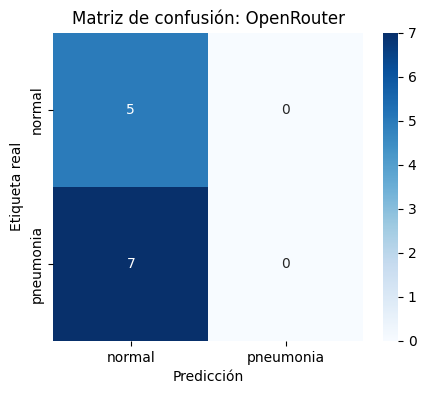

In [59]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    best_metrics["confusion_matrix"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["normal", "pneumonia"],
    yticklabels=["normal", "pneumonia"],
)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title(f"Matriz de confusión: {best_provider}")
plt.show()

In [60]:
comparison_df = prompting_df[["item_id", "label"]].copy()

for provider_name, predictions in provider_predictions.items():
    comparison_df[provider_name] = predictions

comparison_df

,item_id,label,OpenRouter
0,270,pneumonia,normal
1,53,pneumonia,normal
2,475,normal,normal
3,327,pneumonia,normal
4,402,pneumonia,normal
5,530,pneumonia,normal
6,54,normal,normal
7,267,normal,normal
8,58,normal,normal
9,432,pneumonia,normal


## Análisis cualitativo de errores

En problemas médicos pequeños conviene mirar imagen por imagen y no quedarse solo con un número agregado.

In [61]:
analysis_df = prompting_df[["item_id", "label", "image"]].copy()
analysis_df["prediction"] = best_predictions
analysis_df["is_correct"] = analysis_df["label"] == analysis_df["prediction"]

analysis_df

,item_id,label,image,prediction,is_correct
0,270,pneumonia,<PIL.Image.Image image mode=RGB size=224x224 at 0x74C009C5E510>,normal,False
1,53,pneumonia,<PIL.Image.Image image mode=RGB size=224x224 at 0x74C009C6E750>,normal,False
2,475,normal,<PIL.Image.Image image mode=RGB size=224x224 at 0x74C009C6DDF0>,normal,True
3,327,pneumonia,<PIL.Image.Image image mode=RGB size=224x224 at 0x74C009C6E540>,normal,False
4,402,pneumonia,<PIL.Image.Image image mode=RGB size=224x224 at 0x74C009C6CF20>,normal,False
5,530,pneumonia,<PIL.Image.Image image mode=RGB size=224x224 at 0x74C009C6E4B0>,normal,False
6,54,normal,<PIL.Image.Image image mode=RGB size=224x224 at 0x74C009C6D940>,normal,True
7,267,normal,<PIL.Image.Image image mode=RGB size=224x224 at 0x74C009C6E180>,normal,True
8,58,normal,<PIL.Image.Image image mode=RGB size=224x224 at 0x74C009C6EB70>,normal,True
9,432,pneumonia,<PIL.Image.Image image mode=RGB size=224x224 at 0x74C009C6DA00>,normal,False


In [62]:
mistakes_df = analysis_df[analysis_df["is_correct"] == False]
mistakes_df[["item_id", "label", "prediction"]]

,item_id,label,prediction
0,270,pneumonia,normal
1,53,pneumonia,normal
3,327,pneumonia,normal
4,402,pneumonia,normal
5,530,pneumonia,normal
9,432,pneumonia,normal
10,608,pneumonia,normal


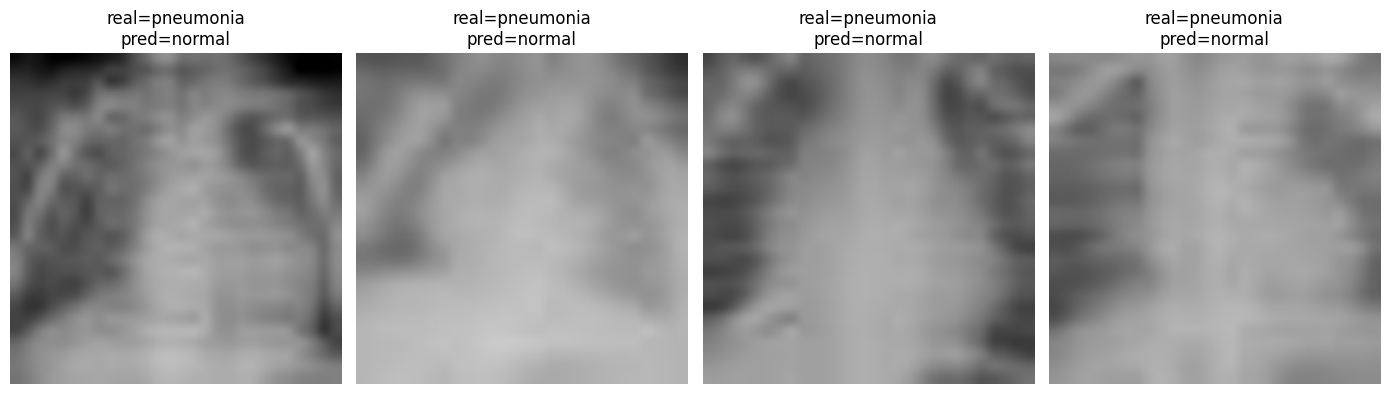

In [63]:
mistakes_to_show = mistakes_df.iloc[:4]
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for axis, (_, row) in zip(axes, mistakes_to_show.iterrows()):
    axis.imshow(row["image"], cmap="gray")
    axis.set_title(f"real={row['label']}\npred={row['prediction']}")
    axis.axis("off")

plt.tight_layout()
plt.show()

## Embeddings visuales con DINOv2

Los modelos multimodales sirven para hacer clasificación zero-shot, pero otra estrategia muy útil es congelar un encoder visual y usar sus embeddings como representación de la imagen.

En el plan del curso aparecía DINOv3 o similar. Aquí usaremos `DINOv2` porque se carga fácilmente desde `timm` y transmite la misma idea docente:

- no entrenamos el backbone visual,
- solo extraemos un vector por imagen,
- y encima entrenamos un clasificador lineal pequeño.

Esto es muy interesante cuando tenemos pocos datos etiquetados y queremos una línea base rápida.

In [64]:
import torch
import timm
from torchvision import transforms
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA

In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dino_model = timm.create_model(
    "vit_small_patch14_dinov2.lvd142m",
    pretrained=True,
    num_classes=0,
)
dino_model = dino_model.to(device)
dino_model.eval()

dino_image_size = dino_model.patch_embed.img_size[0]

embedding_transform = transforms.Compose(
    [
        transforms.Resize((dino_image_size, dino_image_size)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
    ]
)

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

In [66]:
def extract_embeddings(df, model, transform, batch_size=32):
    all_embeddings = []

    with torch.inference_mode():
        for start in tqdm(range(0, len(df), batch_size), desc="Extrayendo embeddings"):
            batch_images = df.iloc[start:start + batch_size]["image"].tolist()
            batch_tensor = torch.stack([transform(image) for image in batch_images]).to(device)
            batch_embeddings = model(batch_tensor).cpu().numpy()
            all_embeddings.append(batch_embeddings)

    return np.vstack(all_embeddings)

In [67]:
X_train = extract_embeddings(embedding_train_df, dino_model, embedding_transform)
X_test = extract_embeddings(embedding_test_df, dino_model, embedding_transform)

y_train = embedding_train_df["label"].to_numpy()
y_test = embedding_test_df["label"].to_numpy()

X_train.shape, X_test.shape

Extrayendo embeddings:   0%|          | 0/10 [00:00<?, ?it/s]

Extrayendo embeddings:   0%|          | 0/4 [00:00<?, ?it/s]

((300, 384), (120, 384))

In [68]:
linear_classifier = LogisticRegression(max_iter=2000)
linear_classifier.fit(X_train, y_train)

embedding_predictions = linear_classifier.predict(X_test)
embedding_metrics = evaluate_predictions(y_test, embedding_predictions, labels=["normal", "pneumonia"])

embedding_metrics

{'accuracy': 0.8,
 'precision_macro': 0.8111111111111111,
 'recall_macro': 0.7511961722488039,
 'f1_macro': 0.7655486812113318,
 'confusion_matrix': array([[25, 19],
        [ 5, 71]])}

In [69]:
embedding_summary = pd.DataFrame(
    [
        {
            "method": "DINOv2 embeddings + logistic regression",
            "accuracy": round(embedding_metrics["accuracy"], 3),
            "precision_macro": round(embedding_metrics["precision_macro"], 3),
            "recall_macro": round(embedding_metrics["recall_macro"], 3),
            "f1_macro": round(embedding_metrics["f1_macro"], 3),
        }
    ]
)

embedding_summary

,method,accuracy,precision_macro,recall_macro,f1_macro
0,DINOv2 embeddings + logistic regression,0.8,0.811,0.751,0.766


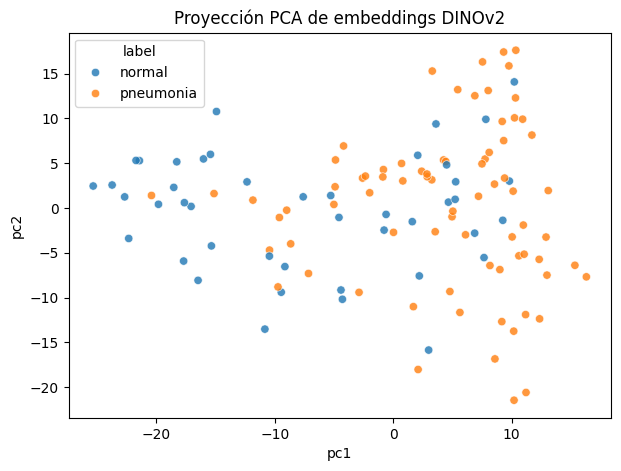

In [70]:
pca = PCA(n_components=2)
embedding_2d = pca.fit_transform(X_test)

plot_df = pd.DataFrame(
    {
        "pc1": embedding_2d[:, 0],
        "pc2": embedding_2d[:, 1],
        "label": y_test,
    }
)

plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="label", alpha=0.8)
plt.title("Proyección PCA de embeddings DINOv2")
plt.show()

## Qué nos llevamos de esta práctica

Hay dos mensajes importantes:

1. Un modelo multimodal puede resolver una tarea de clasificación directamente a partir de la imagen y un buen prompt, sin entrenamiento adicional.
2. Un encoder visual preentrenado también puede servir como extractor de características reutilizable, permitiendo entrenar un clasificador ligero sobre embeddings.

Cuando lleguen las imágenes reales del curso, esta notebook se puede adaptar de dos maneras:

- sustituir `PneumoniaMNIST` por una carpeta propia de imágenes etiquetadas;
- cambiar las etiquetas `normal` y `pneumonia` por `correcta` e `incorrecta`, o por las clases de posicionamiento que se definan.

## Propuestas de ampliación

- Comparar prompts cortos frente a prompts más descriptivos.
- Añadir ejemplos few-shot multimodales con 1 o 2 imágenes de referencia por clase.
- Pedir al modelo una breve justificación clínica y estudiar si ayuda o confunde.
- Comparar las predicciones del mejor provider con el clasificador lineal sobre embeddings.
- Sustituir `PneumoniaMNIST` por un subconjunto real de manos y estudiar si el modelo detecta mejor `correcta` frente a `incorrecta` que una CNN pequeña.